<a href="https://colab.research.google.com/github/231018412-cpu/CSE443assignment/blob/main/problem1/problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from collections import Counter
# Sklearn
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: True


In [ ]:
!apt-get install -y p7zip-full
!pip install -q gdown

!gdown --id 15nvWbtydZGs2B9oXLGgKq8Ll7ObCQy-A

!7z x Archive.7z -o/content/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=15nvWbtydZGs2B9oXLGgKq8Ll7ObCQy-A
From (redirected): https://drive.google.com/uc?id=15nvWbtydZGs2B9oXLGgKq8Ll7ObCQy-A&confirm=t&uuid=b949c53a-90d9-4e43-b986-6796dacd9982
To: /content/Archive.7z
100% 1.23G/1.23G [00:13<00:00, 93.9MB/s]

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         

In [ ]:
import os

BASE_DIR = '/content/' # Changed from '/content/Archive'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

for path, name in [(TRAIN_DIR,'train'), (VAL_DIR,'val'), (TEST_DIR,'test')]:
    print(f"{name}: {'Found' if os.path.exists(path) else 'NOT FOUND'}")

print(os.listdir(BASE_DIR))

train: Found
val: Found
test: Found
['.config', 'test', 'train', '__MACOSX', 'val', 'Archive.7z', 'sample_data']


In [6]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Validation & Test: only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"Classes: {CLASS_NAMES}")
print(f"Class indices: {train_gen.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
 #Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [8]:
def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    # Freeze all layers initially
    base.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model, base

resnet_model, resnet_base = build_resnet50()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
resnet_callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc', mode='max', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
    ModelCheckpoint('best_resnet.keras', save_best_only=True, monitor='val_auc', mode='max', verbose=1)
]

# Phase 1: Train head only
print("Phase 1: Training ResNet50 head (base frozen)...")
resnet_history1 = resnet_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=resnet_callbacks
)

Phase 1: Training ResNet50 head (base frozen)...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.5586 - auc: 0.5936 - loss: 0.7006 - precision: 0.7867 - recall: 0.5481
Epoch 1: val_auc improved from None to 0.85156, saving model to best_resnet.keras

Epoch 1: finished saving model to best_resnet.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 684ms/step - accuracy: 0.6087 - auc: 0.6434 - loss: 0.6650 - precision: 0.8158 - recall: 0.6114 - val_accuracy: 0.6250 - val_auc: 0.8516 - val_loss: 0.6245 - val_precision: 0.5833 - val_recall: 0.8750 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.7048 - auc: 0.7711 - loss: 0.5902 - precision: 0.8770 - recall: 0.7035
Epoch 2: val_auc did not improve from 0.85156
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.7220 - auc: 0.7907 - loss: 0.5727 - precision: 0.8855 - recall: 0.7187 - val_accuracy: 0.5625 - val_auc: 0.8438 - val_loss: 0.6205 - val_precision: 0.5385 - val_recall: 0.875

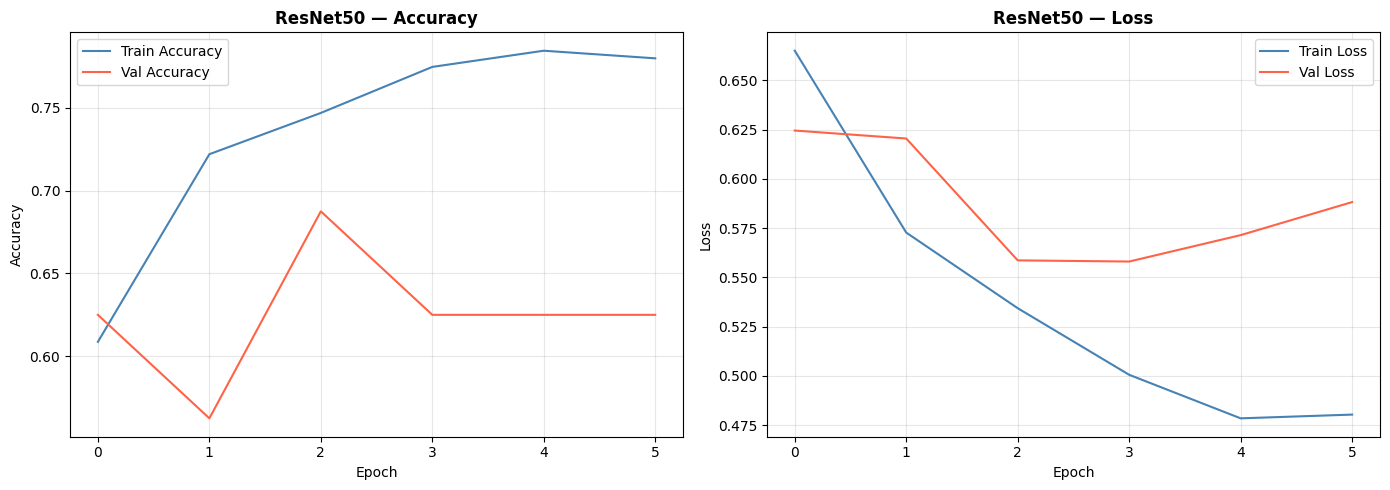

In [13]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato')
    axes[0].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='tomato')
    axes[1].set_title(f'{title} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(resnet_history1, 'ResNet50')


  ResNet50
  Accuracy : 0.7901
  AUC      : 0.8391
              precision    recall  f1-score   support

      NORMAL       0.69      0.79      0.74       234
   PNEUMONIA       0.86      0.79      0.82       390

    accuracy                           0.79       624
   macro avg       0.78      0.79      0.78       624
weighted avg       0.80      0.79      0.79       624



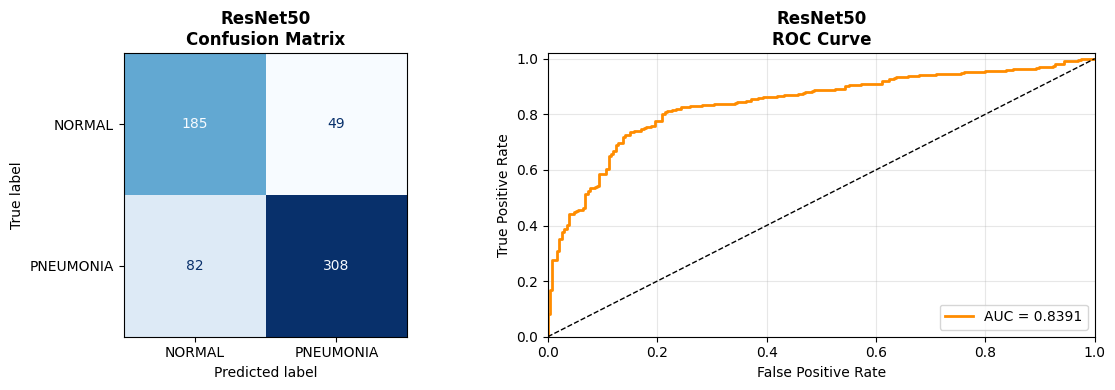

In [14]:
def evaluate_model(model, test_gen, model_name):
    """Full evaluation: accuracy, precision, recall, F1, confusion matrix, ROC."""
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = test_gen.classes

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred,
                                   target_names=list(test_gen.class_indices.keys()),
                                   output_dict=True)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  AUC      : {roc_auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=list(test_gen.class_indices.keys())))

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(test_gen.class_indices.keys()))
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')

    # ROC Curve
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name}\nROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'model': model_name,
        'accuracy': acc,
        'auc': roc_auc,
        'precision': report['weighted avg']['precision'],
        'recall':    report['weighted avg']['recall'],
        'f1':        report['weighted avg']['f1-score'],
        'fpr': fpr,
        'tpr': tpr
    }

results = []

results.append(evaluate_model(resnet_model, test_gen, 'ResNet50'))